In [1]:
#1: importing libraries

import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud


In [2]:
#2: Loading DataSet
df = pd.read_csv("preprocessed_reviews_dataset.csv")
df.head()

,platform,review,rating,date,source,review_length,Original_reviws,tokens,clean_review
0,Cars24,the pdi tool turned my automobile acquiring jo...,5,2026-07-16,Google Play,111,The PDI tool turned my automobile acquiring jo...,"['pdi', 'tool', 'turned', 'automobile', 'acqui...",pdi tool turned automobile acquiring journey f...
1,Cars24,getting to buy a pre owned automobile via this...,5,2026-07-16,Google Play,107,Getting to buy a pre owned automobile via this...,"['getting', 'buy', 'pre', 'owned', 'automobile...",getting buy pre owned automobile via applicati...
2,Cars24,getting to buy a vehicle turned out far simple...,5,2026-07-16,Google Play,221,Getting to buy a vehicle turned out far simple...,"['getting', 'buy', 'vehicle', 'turned', 'far',...",getting buy vehicle turned far simpler utilizi...
3,Cars24,the pdi report explained every detail in a cle...,5,2026-07-16,Google Play,68,The PDI report explained every detail in a cle...,"['pdi', 'report', 'explained', 'every', 'detai...",pdi report explained every detail clear simple...
4,Cars24,i enjoyed a fluid path because the buy journey...,5,2026-07-16,Google Play,89,I enjoyed a fluid path because the buy journey...,"['enjoyed', 'fluid', 'path', 'buy', 'journey',...",enjoyed fluid path buy journey felt safe strai...


In [3]:
#3: Dataset Overview
print("Shape:", df.shape)
df.info()
df.describe(include="all")

Shape: (53379, 9)
<class 'pandas.DataFrame'>
RangeIndex: 53379 entries, 0 to 53378
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   platform         53379 non-null  str  
 1   review           53333 non-null  str  
 2   rating           53379 non-null  int64
 3   date             53296 non-null  str  
 4   source           53379 non-null  str  
 5   review_length    53379 non-null  int64
 6   Original_reviws  53379 non-null  str  
 7   tokens           53379 non-null  str  
 8   clean_review     53309 non-null  str  
dtypes: int64(2), str(7)
memory usage: 3.7 MB


,platform,review,rating,date,source,review_length,Original_reviws,tokens,clean_review
count,53379,53333,53379.000000,53296,53379,53379.000000,53379,53379,53309
unique,2,51062,NaN,2988,2,NaN,53379,49239,49238
top,Cars24,good,NaN,2020-08-17,Google Play,NaN,The PDI tool turned my automobile acquiring jo...,['good'],good
freq,45074,88,NaN,1072,53296,NaN,1,238,238
mean,NaN,NaN,3.262800,NaN,NaN,129.143127,NaN,NaN,NaN
std,NaN,NaN,1.892189,NaN,NaN,127.757831,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,6.000000,NaN,NaN,NaN
25%,NaN,NaN,1.000000,NaN,NaN,34.000000,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,88.000000,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,176.000000,NaN,NaN,NaN


platform
Cars24    45074
Spinny     8305
Name: count, dtype: int64


Text(0, 0.5, 'Reviews')

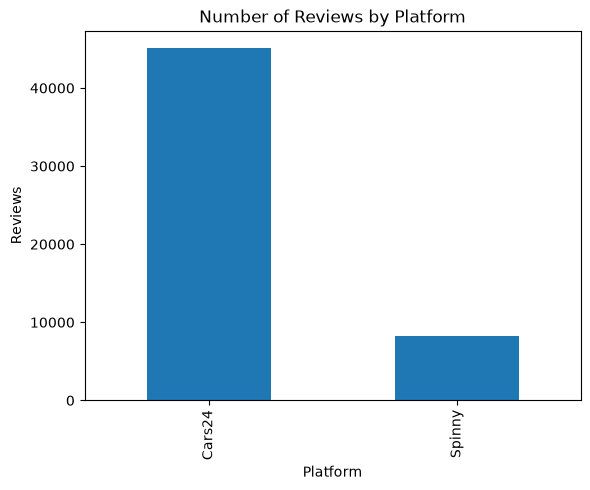

In [4]:
4#: Review Count by Platform
platform_counts = df["platform"].value_counts()

print(platform_counts)

platform_counts.plot(kind="bar")

plt.title("Number of Reviews by Platform")
plt.xlabel("Platform")
plt.ylabel("Reviews")

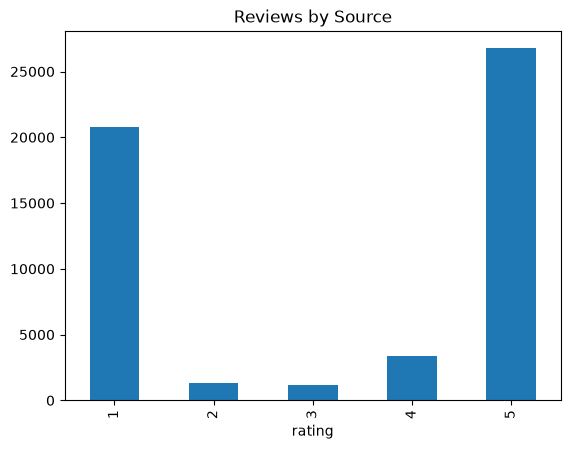

In [5]:
#6: Rating Distribution 

rating_counts = df["rating"].value_counts().sort_index()

rating_counts.plot(kind="bar")

plt.title("Reviews by Source")

plt.show()

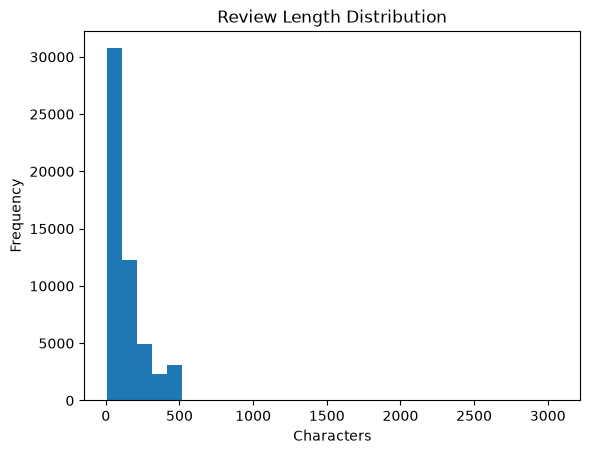

In [7]:
#7: Review Length Distribution

df["review_length"].plot(kind="hist", bins=30)

plt.title("Review Length Distribution")

plt.xlabel("Characters")

plt.show()

In [8]:
df.groupby("platform")["rating"].mean()

platform
Cars24    3.392133
Spinny    2.560867
Name: rating, dtype: float64

In [13]:
#9: Most Common Words
from collections import Counter

all_words = " ".join(df["clean_review"].dropna().astype(str))

word_list = all_words.split()

common_words = Counter(word_list).most_common(20)

common_words


[('car', 48988),
 ('app', 18158),
 ('good', 11468),
 ('price', 11263),
 ('service', 10065),
 ('experience', 8793),
 ('best', 7186),
 ('sell', 7055),
 ('time', 5753),
 ('buy', 5385),
 ('customer', 4952),
 ('selling', 4682),
 ('spinny', 4470),
 ('process', 4457),
 ('worst', 4446),
 ('inspection', 4380),
 ('call', 3835),
 ('one', 3627),
 ('great', 3345),
 ('used', 3323)]

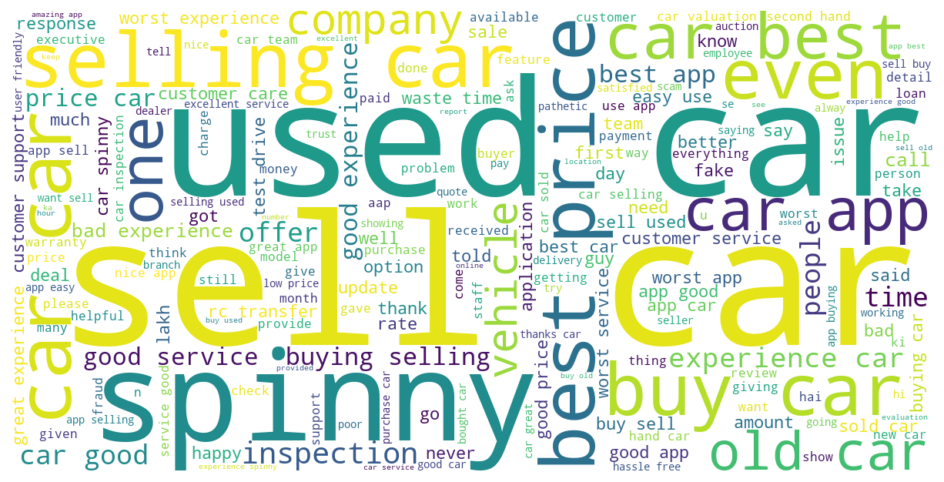

In [18]:
#10: Word Cloud
from wordcloud import WordCloud

text = " ".join(df["clean_review"].dropna().astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
#11: Cars24 Word Cloud
cars24 = df[df["platform"] == "cars24"]

text = " ".join(cars24["clean_review"].dropna().astype(str))

if not text.strip():
    print("No Cars24 reviews available to generate a word cloud.")
else:
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(15,6))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title("Cars24")
    plt.show()

ValueError: We need at least 1 word to plot a word cloud, got 0.